## Preparation

### Imports

In [1]:
import torch
import time
import random
import numpy as np
import math
import torch.nn as nn
from torchinfo import summary
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision import datasets, transforms
from torchmetrics.image.inception import InceptionScore
from torchmetrics.image.fid import FrechetInceptionDistance
from torch.utils.data import DataLoader, random_split, Dataset, ConcatDataset

Matplotlib is building the font cache; this may take a moment.


### GPU check

This section is mainly focused on the device we are about to use and does not interfere with other parts and can be just replaced with the following code:
```python
device = torch.device("cpu")
```

In [2]:
!nvidia-smi

Sun Jun 28 14:56:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.80                 Driver Version: 581.80         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   49C    P5              8W /  140W |     509MiB /   8188MiB |     37%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("Using CPU")

Using CPU


### Randomization control

In [4]:
base_seed = 42
torch.manual_seed(base_seed)
np.random.seed(base_seed)
random.seed(base_seed)
torch.cuda.manual_seed_all(base_seed)

### Constants

In [5]:
NOISE_DIMENSION = 100
NOISE_DIMENSION_LIST = [32, 100, 200]
D_CRITERION = nn.BCEWithLogitsLoss()
G_CRITERION = nn.BCEWithLogitsLoss()
LEARNING_RATE = 0.0002
LEARNING_RATE_LIST = [0.001, 0.0002, 0.0001]
NUM_EPOCH = 100
NUM_EPOCH_LIST = [20, 50, 100]
BATCH_SIZE = 128
BATCH_SIZE_LIST = [32, 128, 256]

## Loading Datasets

### MNIST

In [20]:
class MNIST_DATA:
    def __init__(self):
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

        train_val_dataset = datasets.MNIST(root="./Data", train=True, download=True, transform=self.transform)
        self.test_dataset = datasets.MNIST(root="./Data", train=False, download=True, transform=self.transform)
        self.train_dataset, self.val_dataset = random_split(train_val_dataset, [50000, 10000])
        self.class_names = [str(i) for i in range(10)]

    def get_loaders(self, batch_size=32):
        train_loader = DataLoader(self.train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(self.val_dataset, batch_size=batch_size, shuffle=False)
        test_loader = DataLoader(self.test_dataset, batch_size=batch_size, shuffle=False)
        return train_loader, val_loader, test_loader

    def get_class_names(self):
        return {i: name for i, name in enumerate(self.class_names)}

### SVHN

In [19]:
class SVHN_DATA:
    def __init__(self):
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5),
                                 (0.5, 0.5, 0.5))
        ])

        train_val_dataset = datasets.SVHN(root="./Data/SVHN", split="train", download=True, transform=self.transform)
        self.test_dataset = datasets.SVHN(root="./Data/SVHN", split="test", download=True, transform=self.transform)
        self.train_dataset, self.val_dataset = random_split(train_val_dataset, [60000, 13257])
        self.class_names = [str(i) for i in range(10)]

    def get_loaders(self, batch_size=32):
        train_loader = DataLoader(self.train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(self.val_dataset, batch_size=batch_size, shuffle=False)
        test_loader = DataLoader(self.test_dataset, batch_size=batch_size, shuffle=False)
        return train_loader, val_loader, test_loader

    def get_class_names(self):
        return {i: name for i, name in enumerate(self.class_names)}

### CelebA

In [21]:
class CelebA_DATA:
    def __init__(self):
        self.transform = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5),
                                 (0.5, 0.5, 0.5))
        ])

        self.train_dataset = datasets.CelebA(root="./Data", split="train", target_type="attr", download=True, transform=self.transform)
        self.val_dataset = datasets.CelebA(root="./Data", split="valid", target_type="attr", download=True, transform=self.transform)
        self.test_dataset = datasets.CelebA(root="./Data", split="test", target_type="attr", download=True, transform=self.transform)
        self.class_names = self.train_dataset.attr_names

    def get_loaders(self, batch_size=32):
        train_loader = DataLoader(self.train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(self.val_dataset, batch_size=batch_size, shuffle=False)
        test_loader = DataLoader(self.test_dataset, batch_size=batch_size, shuffle=False)
        return train_loader, val_loader, test_loader

    def get_class_names(self):
        return {i: name for i, name in enumerate(self.class_names)}

### Visualization

In [35]:
def show_batch(loader, class_names=None, n_cols=8, show_label=False, max_attrs=3):
    images, labels = next(iter(loader))
    batch_size = len(images)
    n_rows = math.ceil(batch_size / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2 * n_cols, 2 * n_rows), squeeze=False,)

    axes = axes.ravel()
    for ax in axes:
        ax.axis("off")
    for i, (img, label) in enumerate(zip(images, labels)):
        img = img * 0.5 + 0.5
        img = img.clamp(0, 1)
        if img.shape[0] == 1:
            axes[i].imshow(img.squeeze(), cmap="gray")
        else:
            axes[i].imshow(img.permute(1, 2, 0))
        if label.ndim == 0:
            label = label.item()
            title = class_names[label] if class_names is not None else str(label)
        else:
            active = torch.where(label == 1)[0].tolist()
            if class_names is not None:
                attrs = [class_names[j] for j in active[:max_attrs]]
            else:
                attrs = [str(j) for j in active[:max_attrs]]
            if len(active) > max_attrs:
                attrs.append("...")
            title = "\n".join(attrs)
        if show_label:
            axes[i].set_title(title, fontsize=10)

    plt.tight_layout()
    plt.show()

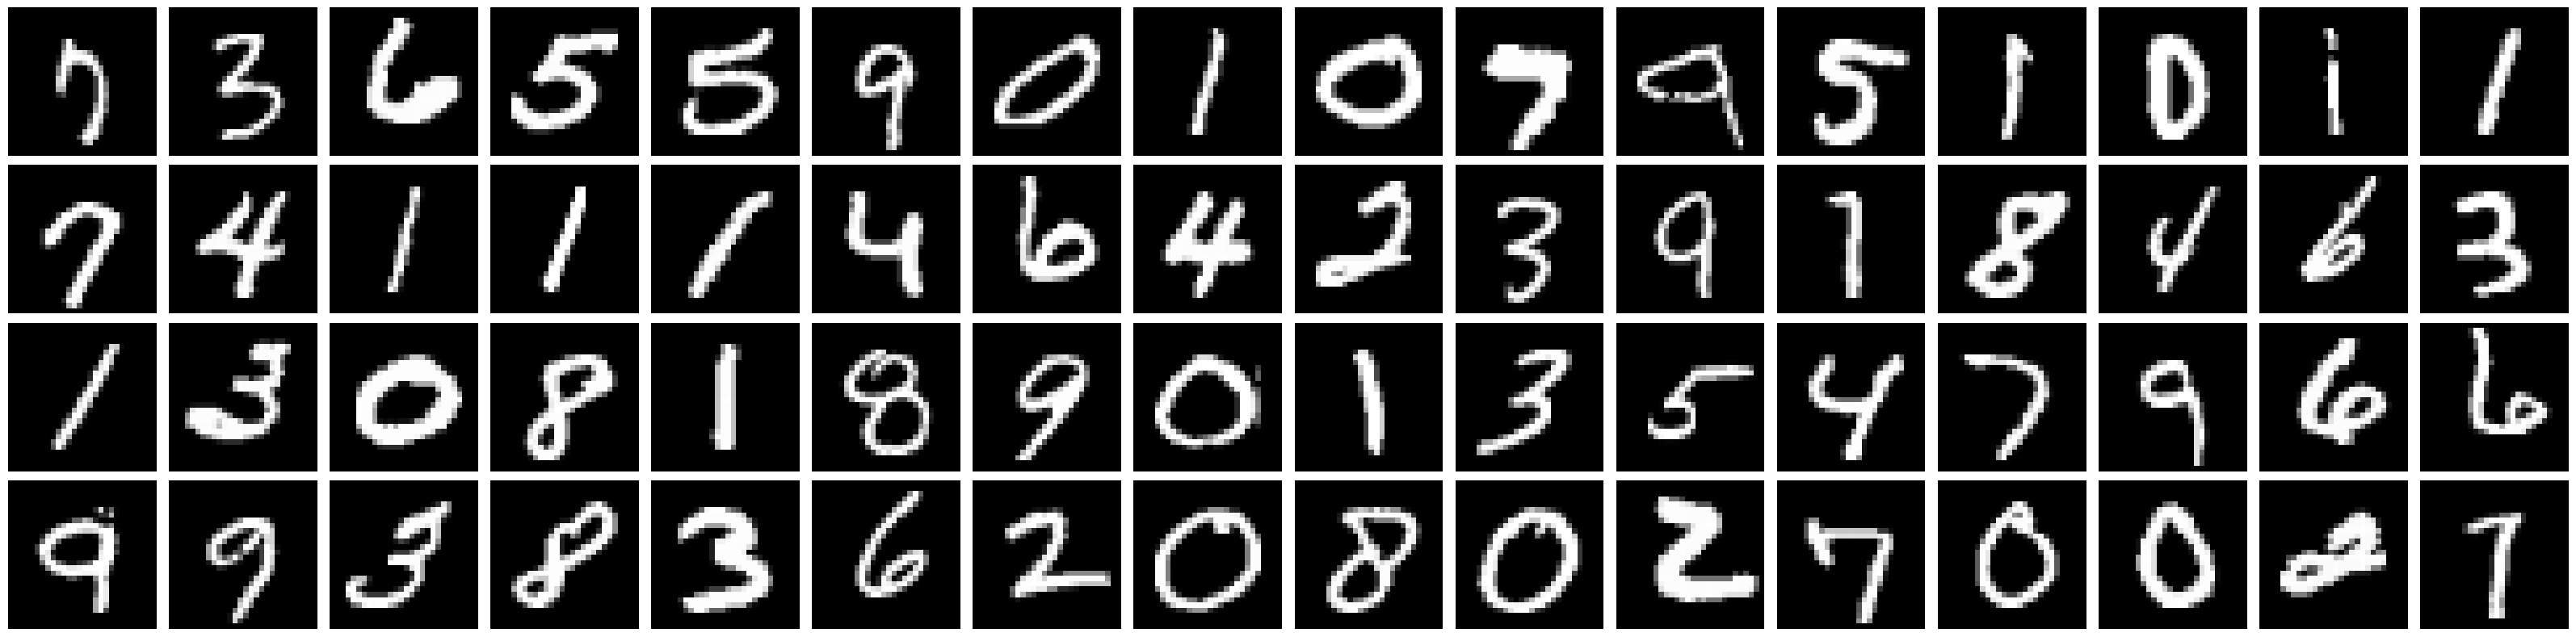

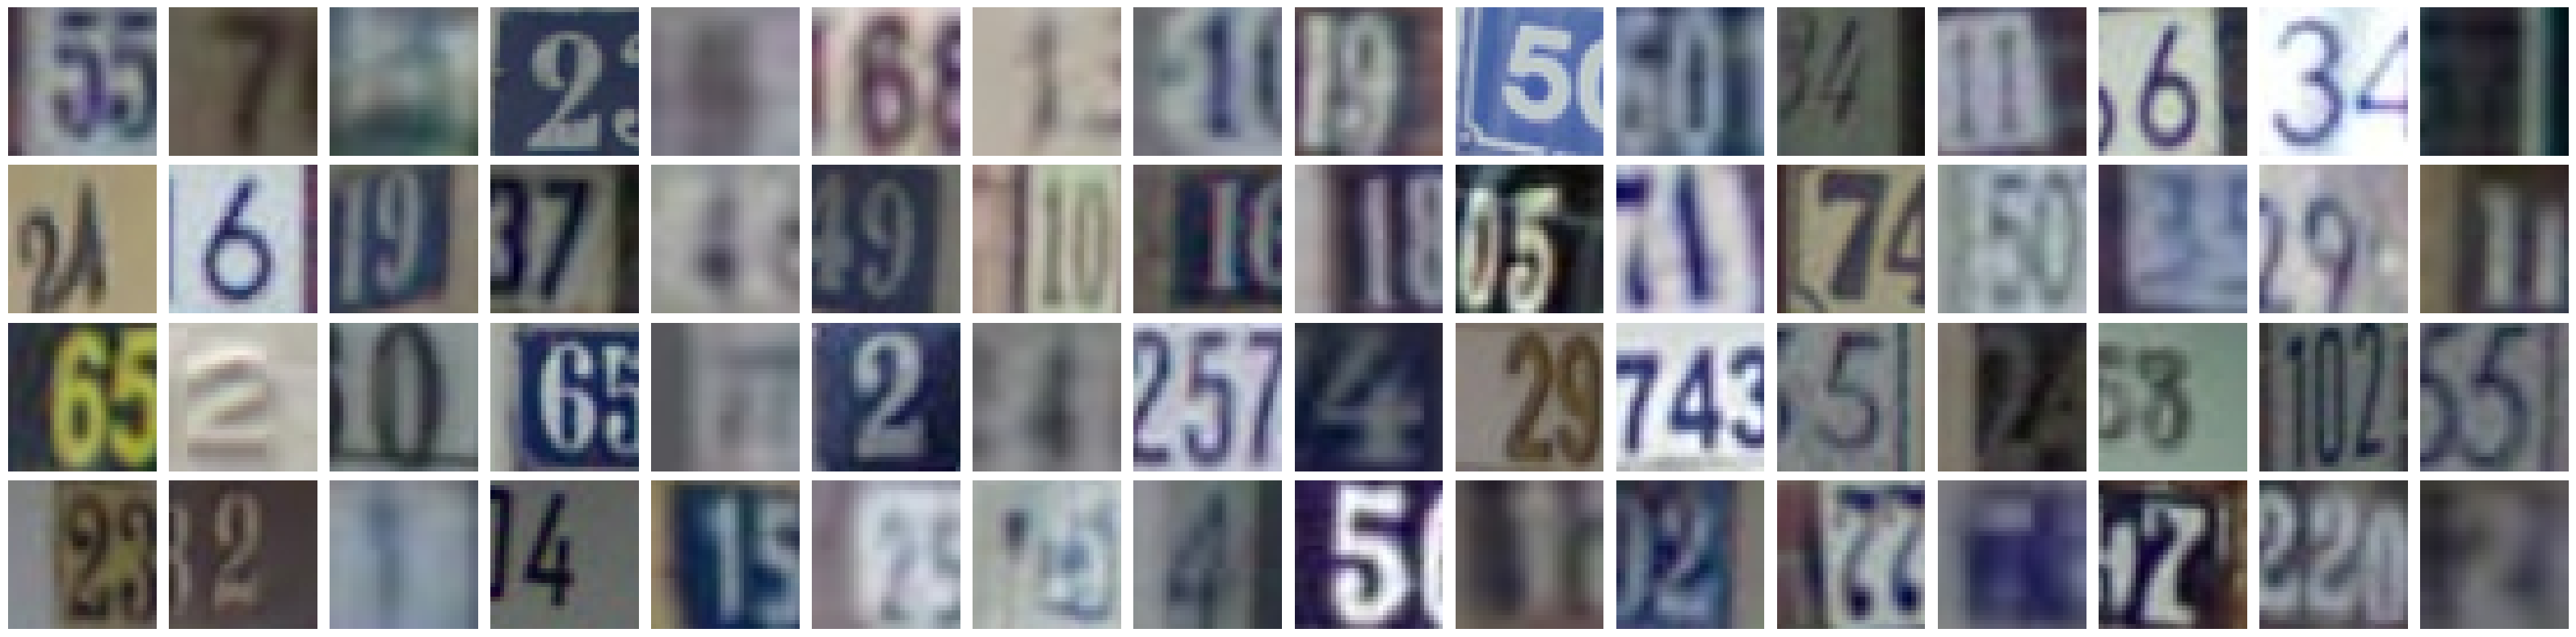

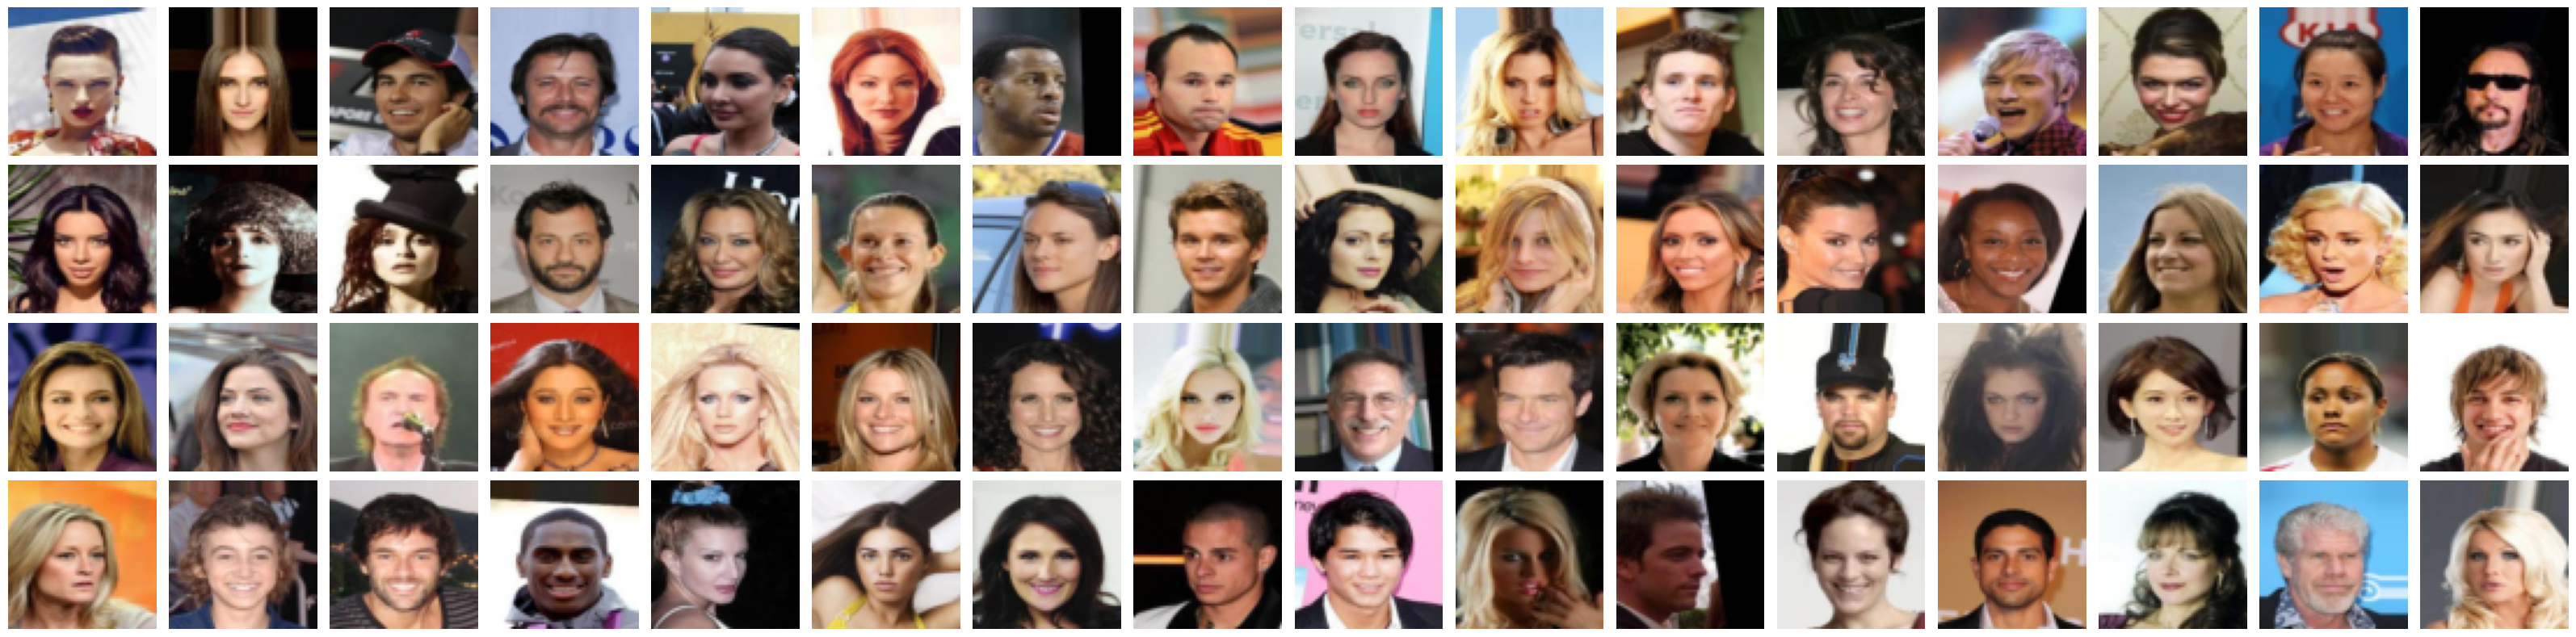

In [36]:
mnist = MNIST_DATA()
mnist_train, mnist_val, mnist_test = mnist.get_loaders(batch_size=64)
show_batch(mnist_train, class_names=mnist.get_class_names(), n_cols=16)
svhn = SVHN_DATA()
svhn_train, svhn_val, svhn_test = svhn.get_loaders(batch_size=64)
show_batch(svhn_train, class_names=svhn.get_class_names(), n_cols=16)
celeb = CelebA_DATA()
celeb_train, celeb_val, celeb_test = celeb.get_loaders(batch_size=64)
show_batch(celeb_train, class_names=celeb.get_class_names(), n_cols=16)
